<a href="https://colab.research.google.com/github/hafisc/pcvk_2026/blob/main/Pertemuan%20Ke%203/praktikum3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Mohammad Al Hafis Hidayatulloh'
NIM = '254107023005'
N = int(NIM[-3:])

PARAM = {
    'b' : (N % 61) + 20,
    'a' : round(1.0 + (N % 9) / 10, 1),
    'c' : (N % 20) + 30,
    'gamma': round(0.4 + (N % 6) * 0.25, 2),
    'bit' : (N % 6) + 2,
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA  :', NAMA)
print('NIM   :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM:', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA  : Mohammad Al Hafis Hidayatulloh
NIM   : 254107023005 | N = 5
b      : 25
a      : 1.5
c      : 35
gamma  : 1.65
bit    : 7
WAKTU : 2026-09-29 02:19:40 WIB
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 87b8477d37971fdf


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt

BASE_PATH = '/content/drive/MyDrive/pcvk_2026/'

path_gelap = BASE_PATH + 'ktm_gelap.jpeg'
path_ruang = BASE_PATH + 'ktm_ruang.jpeg'
path_flash = BASE_PATH + 'ktm_flash.jpeg'
path_terang = BASE_PATH + 'ktm_terang.jpeg'
path_benda = BASE_PATH + 'foto_benda.jpeg'
path_malam = BASE_PATH + 'Pemandangan_malam.jpeg'
path_galaxy = BASE_PATH + 'galaxy.jpg'
path_noises = BASE_PATH + 'noises/*.jpg'


## Tugas 1: Inverse Citra\nImplementasi inverse citra pada citra ruang gelap (ktm_gelap) dan terang (ktm_ruang).


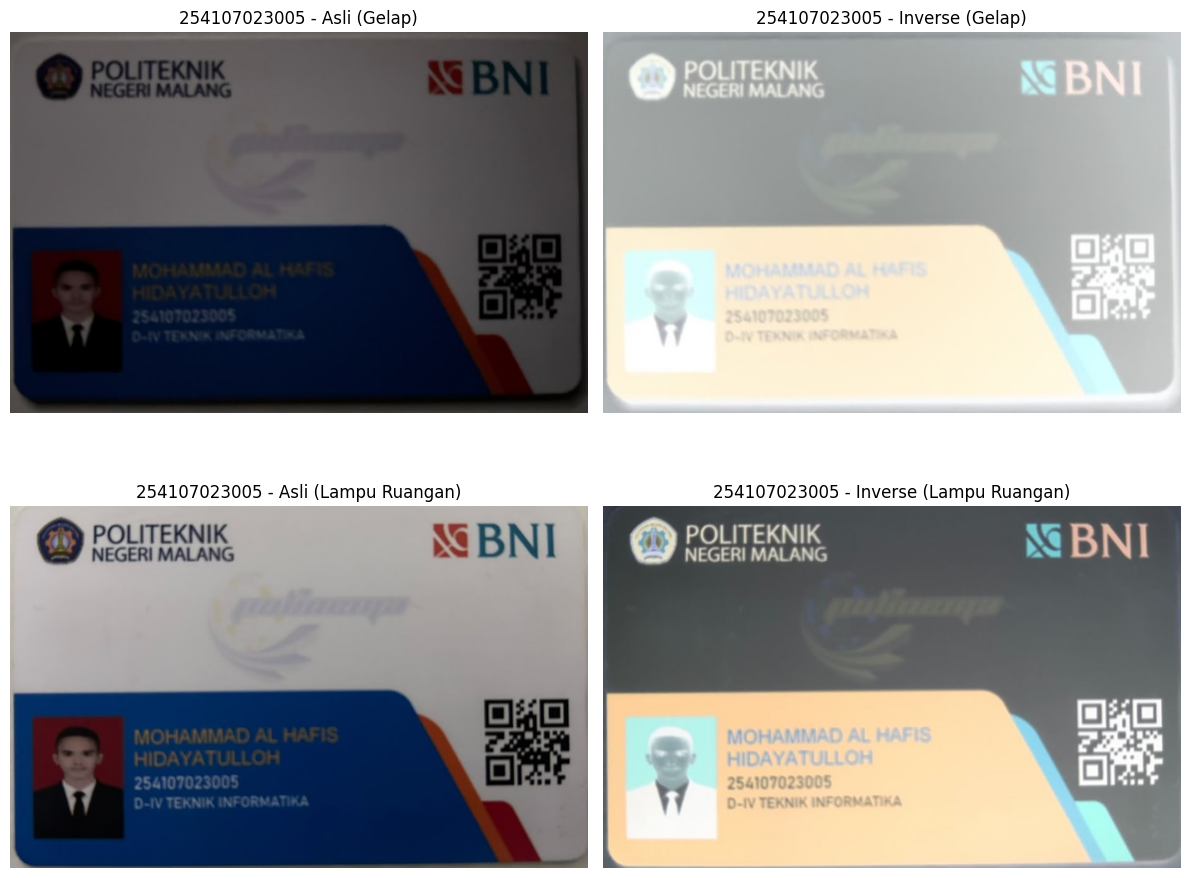

=== ANALISIS TUGAS 1 ===
Mengapa citra negatif dari ruangan gelap tampak pucat dan berkabut, sedangkan negatif dari lampu ruangan tetap kontras?
Jawab: Citra yang gelap memiliki sebagian besar nilai piksel mendekati 0 (hitam). Ketika di-inverse (255 - piksel), nilainya berbalik menjadi rentang angka yang tinggi (mendekati 255 / terang). Karena minimnya variasi warna di gambar aslinya (kurang kontras), hasil inversenya juga menjadi sekadar hamparan warna terang yang datar tanpa tekstur, sehingga terlihat pucat dan berkabut.


In [4]:
img_gelap = cv.imread(path_gelap)
img_ruang = cv.imread(path_ruang)

if img_gelap is not None and img_ruang is not None:
    img_gelap = cv.cvtColor(img_gelap, cv.COLOR_BGR2RGB)
    img_ruang = cv.cvtColor(img_ruang, cv.COLOR_BGR2RGB)

    # Operasi inverse
    inv_gelap = 255 - img_gelap
    inv_ruang = 255 - img_ruang

    plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1); plt.imshow(img_gelap); plt.title(f"{NIM} - Asli (Gelap)"); plt.axis('off')
    plt.subplot(2, 2, 2); plt.imshow(inv_gelap); plt.title(f"{NIM} - Inverse (Gelap)"); plt.axis('off')
    plt.subplot(2, 2, 3); plt.imshow(img_ruang); plt.title(f"{NIM} - Asli (Lampu Ruangan)"); plt.axis('off')
    plt.subplot(2, 2, 4); plt.imshow(inv_ruang); plt.title(f"{NIM} - Inverse (Lampu Ruangan)"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 1 ===")
    print("Mengapa citra negatif dari ruangan gelap tampak pucat dan berkabut, sedangkan negatif dari lampu ruangan tetap kontras?")
    print("Jawab: Citra yang gelap memiliki sebagian besar nilai piksel mendekati 0 (hitam). Ketika di-inverse (255 - piksel), nilainya berbalik menjadi rentang angka yang tinggi (mendekati 255 / terang). Karena minimnya variasi warna di gambar aslinya (kurang kontras), hasil inversenya juga menjadi sekadar hamparan warna terang yang datar tanpa tekstur, sehingga terlihat pucat dan berkabut.")



## Tugas 2: Transformasi Kontras\nTransformasi kontras dengan nilai a yang dihitung dari NIM.


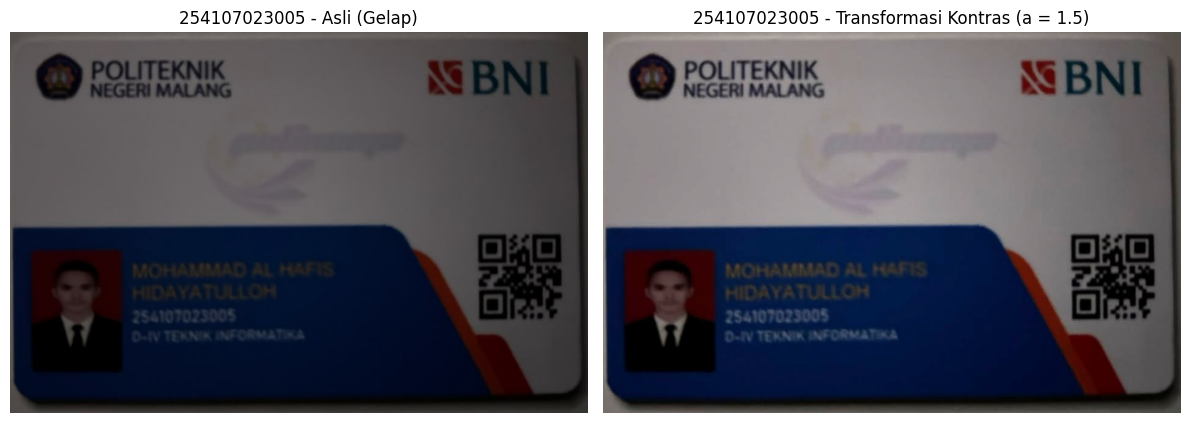

In [5]:
a = PARAM['a']
b = 0 # Asumsi kecerahan tidak ditambah

if img_gelap is not None:
    # Operasi g(x,y) = a * f(x,y) + b
    # Konversi ke float32 untuk menghindari overflow sebelum dilimit
    kontras_gelap = np.clip(img_gelap.astype(np.float32) * a + b, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img_gelap); plt.title(f"{NIM} - Asli (Gelap)"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(kontras_gelap); plt.title(f"{NIM} - Transformasi Kontras (a = {a})"); plt.axis('off')
    plt.tight_layout()
    plt.show()



## Tugas 3: Transformasi Logarithmic vs Linier Brightness


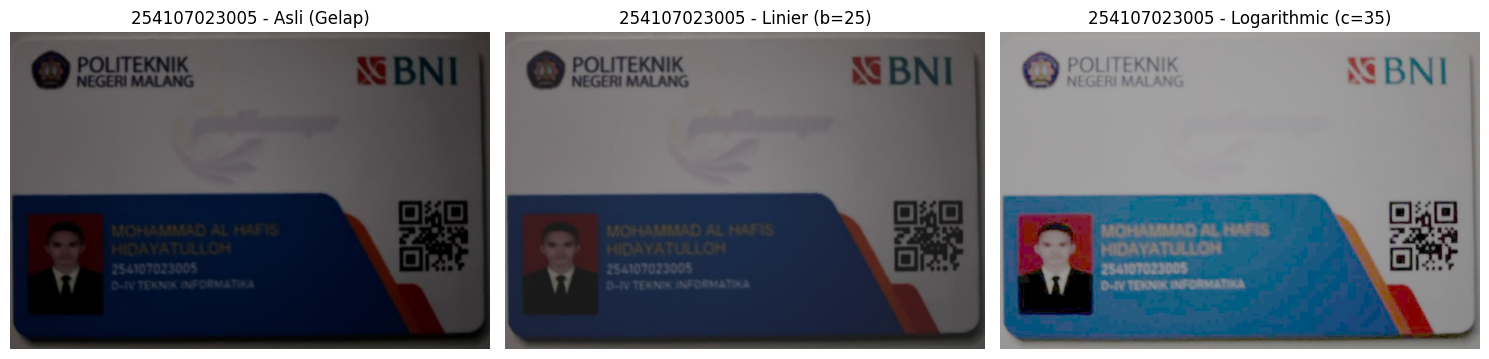

=== ANALISIS TUGAS 3 ===
Metode mana yang membuat NIM pada kartu lebih terbaca? Bagian mana yang clipping?
Jawab:
- Metode Logarithmic Brightness membuat detail huruf NIM jauh lebih jelas dibanding Linier. Hal ini dikarenakan operasi logaritma menggeser rentang warna gelap menjadi lebih terang secara terukur, sambil menekan angka yang sudah terang agar tidak berlebihan.
- Clipping (Putih Penuh): Pada metode Linier Brightness, background yang awalnya agak terang langsung mentok di angka 255 (clipping) karena ditambah nilai b yang sama rata. Pada Logarithmic, efek clipping ini jauh lebih sedikit dan detail tetap ada.


In [6]:
b_val = PARAM['b']
c_val = PARAM['c']

if img_gelap is not None:
    # Linier Brightness
    linier_gelap = np.clip(img_gelap.astype(np.float32) + b_val, 0, 255).astype(np.uint8)

    # Logarithmic Brightness: s = c * log(1 + r)
    log_gelap = np.clip(c_val * np.log1p(img_gelap.astype(np.float32)), 0, 255).astype(np.uint8)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img_gelap); plt.title(f"{NIM} - Asli (Gelap)"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(linier_gelap); plt.title(f"{NIM} - Linier (b={b_val})"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(log_gelap); plt.title(f"{NIM} - Logarithmic (c={c_val})"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 3 ===")
    print("Metode mana yang membuat NIM pada kartu lebih terbaca? Bagian mana yang clipping?")
    print("Jawab:")
    print("- Metode Logarithmic Brightness membuat detail huruf NIM jauh lebih jelas dibanding Linier. Hal ini dikarenakan operasi logaritma menggeser rentang warna gelap menjadi lebih terang secara terukur, sambil menekan angka yang sudah terang agar tidak berlebihan.")
    print("- Clipping (Putih Penuh): Pada metode Linier Brightness, background yang awalnya agak terang langsung mentok di angka 255 (clipping) karena ditambah nilai b yang sama rata. Pada Logarithmic, efek clipping ini jauh lebih sedikit dan detail tetap ada.")



## Tugas 4: Grayscale (Averaging, Lightness, Luminance)


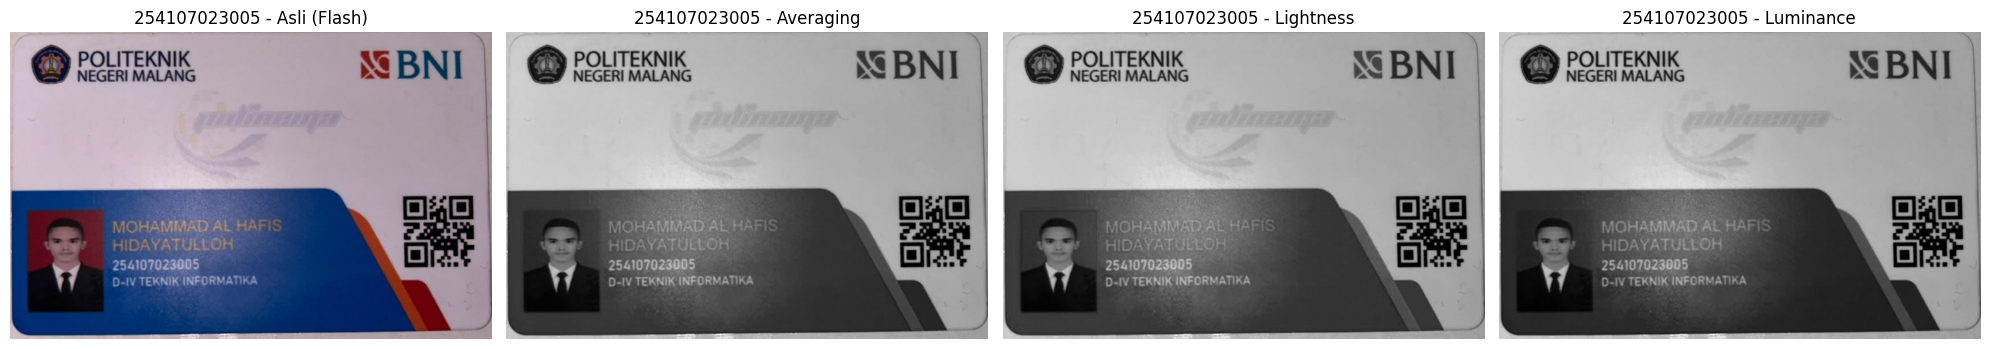

=== ANALISIS TUGAS 4 ===
Metode          | Rata-rata       | Simpangan Baku 
--------------------------------------------------
Averaging       | 128.9580        | 59.6102        
Lightness       | 130.2135        | 57.6093        
Luminance       | 123.4555        | 61.9923        
--------------------------------------------------

Metode mana yang memberi pemisahan paling jelas?
Jawab: Luminance. Karena rumus luminance memberikan prioritas bobot berdasarkan sensitivitas penglihatan mata manusia terhadap warna tertentu (hijau paling tinggi, kemudian merah, dan biru paling rendah). Ini menghasilkan terjemahan citra warna ke abu-abu yang jauh lebih tajam dan membedakan antara teks dengan kartu secara lebih natural dibandingkan rata-rata biasa.


In [7]:
img_flash = cv.imread(path_flash)
if img_flash is not None:
    img_flash = cv.cvtColor(img_flash, cv.COLOR_BGR2RGB)

    R = img_flash[:,:,0].astype(np.float32)
    G = img_flash[:,:,1].astype(np.float32)
    B = img_flash[:,:,2].astype(np.float32)

    # 1. Averaging
    gray_avg = np.mean(img_flash, axis=2).astype(np.uint8)

    # 2. Lightness (max(R,G,B) + min(R,G,B))/2
    gray_lightness = ((np.max(img_flash, axis=2).astype(np.float32) + np.min(img_flash, axis=2).astype(np.float32)) / 2).astype(np.uint8)

    # 3. Luminance (Rec. 601: 0.299R + 0.587G + 0.114B)
    gray_luminance = (0.299 * R + 0.587 * G + 0.114 * B).astype(np.uint8)

    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1); plt.imshow(img_flash); plt.title(f"{NIM} - Asli (Flash)"); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(gray_avg, cmap='gray'); plt.title(f"{NIM} - Averaging"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(gray_lightness, cmap='gray'); plt.title(f"{NIM} - Lightness"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(gray_luminance, cmap='gray'); plt.title(f"{NIM} - Luminance"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 4 ===")
    print(f"{'Metode':<15} | {'Rata-rata':<15} | {'Simpangan Baku':<15}")
    print("-" * 50)
    print(f"{'Averaging':<15} | {np.mean(gray_avg):<15.4f} | {np.std(gray_avg):<15.4f}")
    print(f"{'Lightness':<15} | {np.mean(gray_lightness):<15.4f} | {np.std(gray_lightness):<15.4f}")
    print(f"{'Luminance':<15} | {np.mean(gray_luminance):<15.4f} | {np.std(gray_luminance):<15.4f}")
    print("-" * 50)
    print("\nMetode mana yang memberi pemisahan paling jelas?")
    print("Jawab: Luminance. Karena rumus luminance memberikan prioritas bobot berdasarkan sensitivitas penglihatan mata manusia terhadap warna tertentu (hijau paling tinggi, kemudian merah, dan biru paling rendah). Ini menghasilkan terjemahan citra warna ke abu-abu yang jauh lebih tajam dan membedakan antara teks dengan kartu secara lebih natural dibandingkan rata-rata biasa.")



## Tugas 5: Seleksi Warna HSV


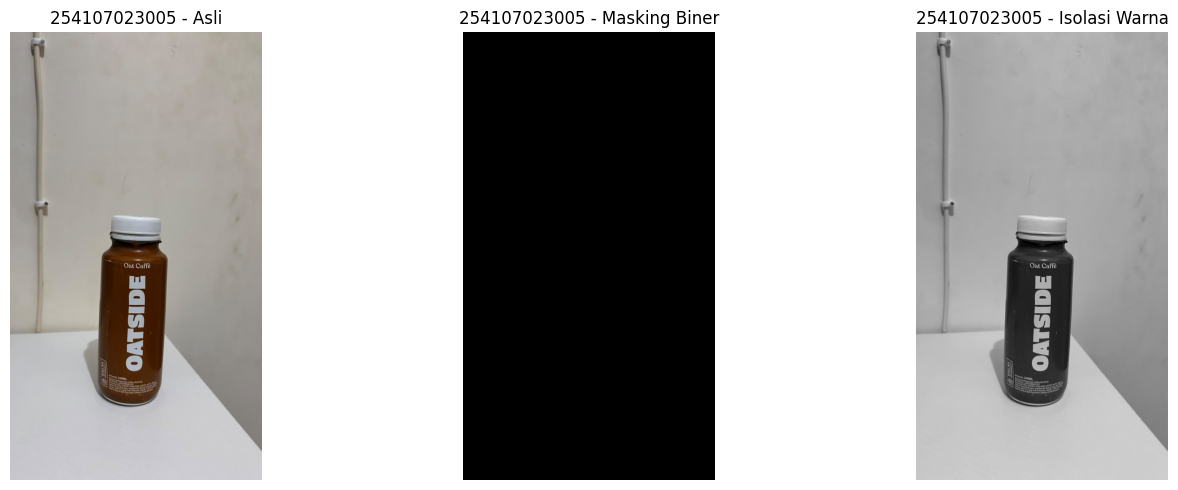

=== ANALISIS TUGAS 5 ===
Rentang HSV yang dipakai: [90 50 50] sampai [130 255 255]
Pengaruh jika rentang diperlebar:
- Seleksi terlalu luas, warna-warna lain di latar belakang atau benda lain yang agak mirip akan ikut terpilih dan gagal berubah menjadi abu-abu.
Pengaruh jika rentang dipersempit:
- Seleksi terlalu kaku, bayangan gelap pada objek atau pantulan cahaya terang di badan objek tidak masuk rentang, akibatnya objek utama malah ikut menjadi abu-abu secara belang-belang.


In [8]:
img_benda = cv.imread(path_benda)
if img_benda is None:
    print("Catatan: foto_benda.jpeg belum ada. Menggunakan ktm_terang.jpeg sebagai sampel.")
    img_benda = cv.imread(path_terang)

if img_benda is not None:
    img_benda_rgb = cv.cvtColor(img_benda, cv.COLOR_BGR2RGB)
    img_benda_hsv = cv.cvtColor(img_benda, cv.COLOR_BGR2HSV)

    # Rentang warna yang dipilih (Contoh: Coklat gelap botol Oatside)
    # *Silakan sesuaikan jika benda kamu warnanya berbeda!*
    lower_bound = np.array([0, 20, 20])
    upper_bound = np.array([30, 255, 200])

    # Buat mask
    mask = cv.inRange(img_benda_hsv, lower_bound, upper_bound)
    mask_inv = cv.bitwise_not(mask)

    # Ekstrak bagian yang sesuai warna
    foreground = cv.bitwise_and(img_benda_rgb, img_benda_rgb, mask=mask)

    # Jadikan sisanya grayscale
    gray_bg = cv.cvtColor(img_benda, cv.COLOR_BGR2GRAY)
    gray_bg_rgb = cv.cvtColor(gray_bg, cv.COLOR_GRAY2RGB)
    background = cv.bitwise_and(gray_bg_rgb, gray_bg_rgb, mask=mask_inv)

    # Gabung
    img_hasil_masking = cv.add(foreground, background)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img_benda_rgb); plt.title(f"{NIM} - Asli"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(mask, cmap='gray'); plt.title(f"{NIM} - Masking Biner"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(img_hasil_masking); plt.title(f"{NIM} - Isolasi Warna"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 5 ===")
    print(f"Rentang HSV yang dipakai: {lower_bound} sampai {upper_bound}")
    print("Pengaruh jika rentang diperlebar:")
    print("- Seleksi terlalu luas, warna-warna lain di latar belakang atau benda lain yang agak mirip akan ikut terpilih dan gagal berubah menjadi abu-abu.")
    print("Pengaruh jika rentang dipersempit:")
    print("- Seleksi terlalu kaku, bayangan gelap pada objek atau pantulan cahaya terang di badan objek tidak masuk rentang, akibatnya objek utama malah ikut menjadi abu-abu secara belang-belang.")




## Tugas 6: Gamma Correction


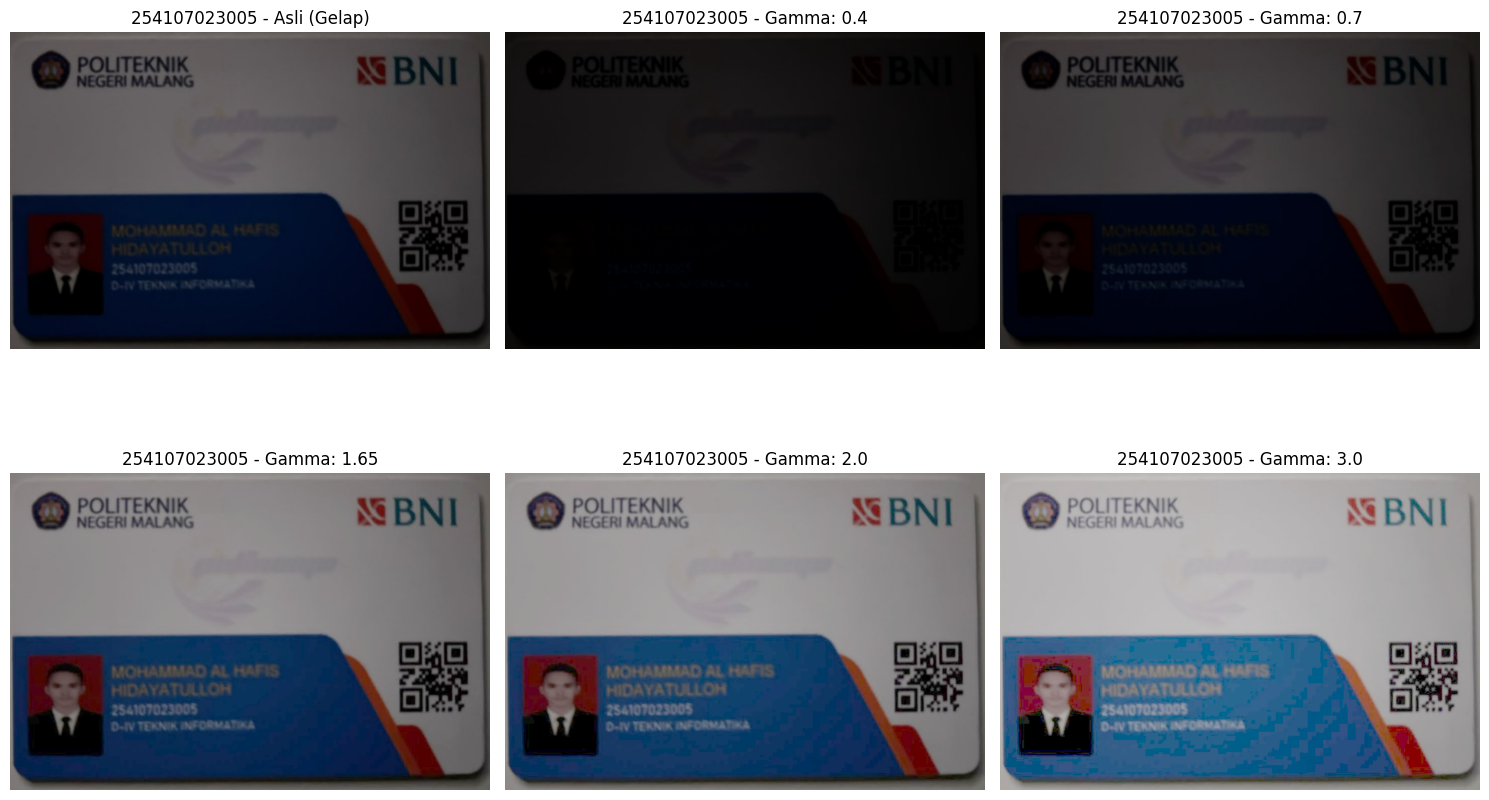

=== ANALISIS TUGAS 6 ===
Mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama?
Jawab: Nilai Gamma bertindak seperti peregang cahaya logaritmik. Meskipun kita semua memfoto KTM, kondisi gelap dari ruangan tiap mahasiswa berbeda (faktor lampu, bayangan jendela, kualitas sensor kamera). Karena derajat kegelapannya unik, maka derajat koreksi kurva gamma yang dibutuhkan untuk mengangkat detail wajah dan huruf juga pasti unik per foto.


In [9]:
gamma_param = PARAM['gamma']
list_gamma = [0.4, 0.7, gamma_param, 2.0, 3.0]

if img_gelap is not None:
    plt.figure(figsize=(15, 10))
    plt.subplot(2, 3, 1); plt.imshow(img_gelap); plt.title(f"{NIM} - Asli (Gelap)"); plt.axis('off')

    for i, g in enumerate(list_gamma):
        inv_gamma = 1.0 / g
        img_g = np.clip(255.0 * np.power(img_gelap / 255.0, inv_gamma), 0, 255).astype(np.uint8)

        plt.subplot(2, 3, i + 2)
        plt.imshow(img_g)
        plt.title(f"{NIM} - Gamma: {g}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 6 ===")
    print("Mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama?")
    print("Jawab: Nilai Gamma bertindak seperti peregang cahaya logaritmik. Meskipun kita semua memfoto KTM, kondisi gelap dari ruangan tiap mahasiswa berbeda (faktor lampu, bayangan jendela, kualitas sensor kamera). Karena derajat kegelapannya unik, maka derajat koreksi kurva gamma yang dibutuhkan untuk mengangkat detail wajah dan huruf juga pasti unik per foto.")



## Tugas 7: Simulasi Image Depth


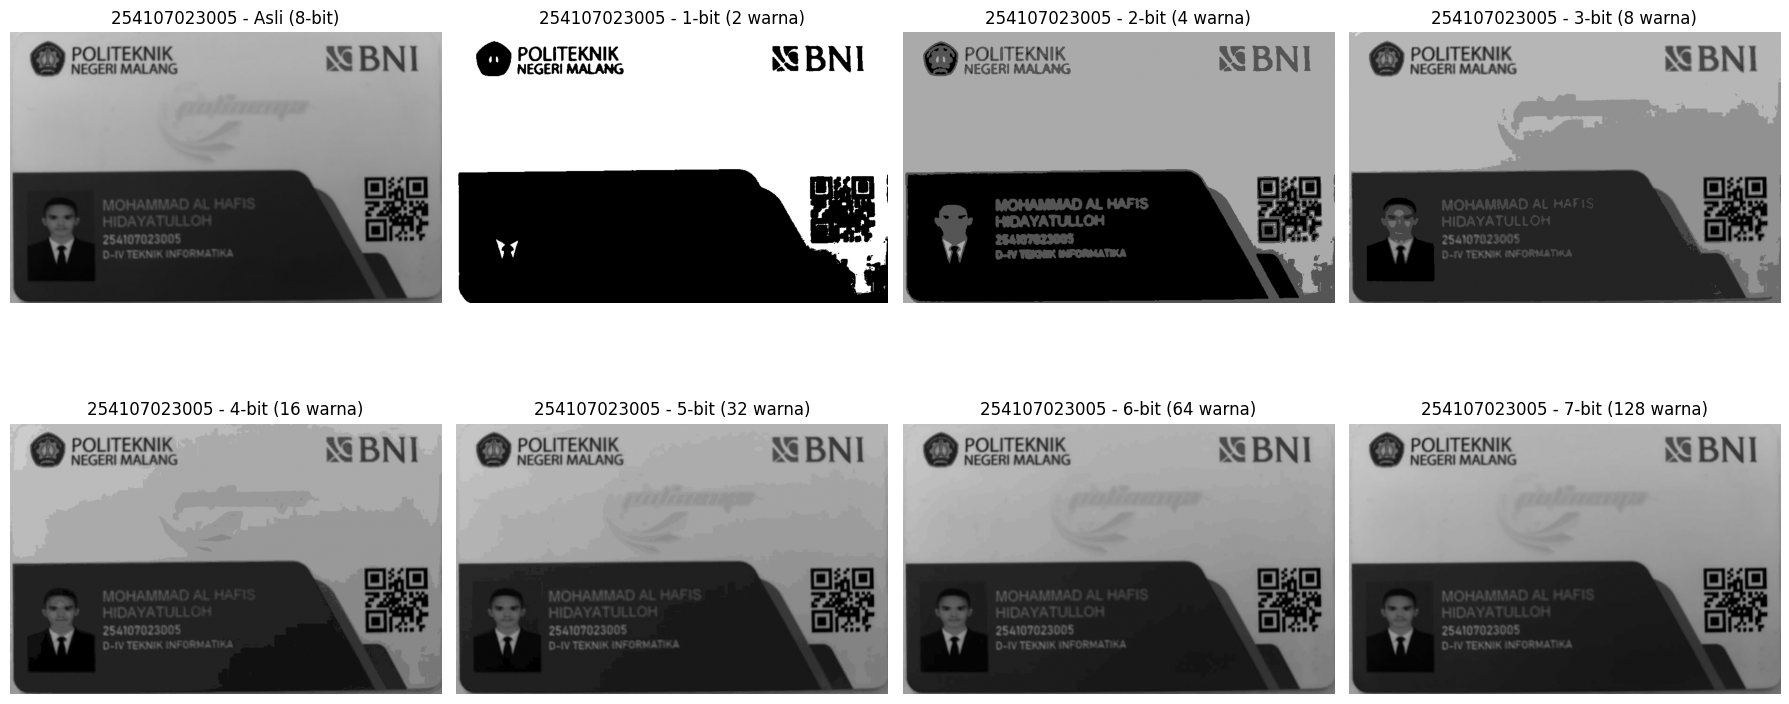

=== ANALISIS TUGAS 7 ===
Pada kedalaman berapa nama dan NIM mulai terbaca?
Jawab:
- Pada kedalaman 1-bit dan 2-bit, citra rusak karena posterisasi tinggi, teks menyatu dengan latar belakang dan tidak terbaca.
- Mulai di kedalaman 3-bit, gradasi abu-abu mulai membedakan hitamnya teks dengan latar, dan pada 4-bit (16 gradasi) teks sudah bisa dibaca dengan cukup jelas.


In [10]:
# Konversi ke Grayscale untuk simulasi kuantisasi
img_ruang2 = cv.imread(path_ruang)
if img_ruang2 is not None:
    img_ruang_gray = cv.cvtColor(img_ruang2, cv.COLOR_BGR2GRAY)

    plt.figure(figsize=(18, 9))
    plt.subplot(2, 4, 1); plt.imshow(img_ruang_gray, cmap='gray', vmin=0, vmax=255); plt.title(f"{NIM} - Asli (8-bit)"); plt.axis('off')

    for bit in range(1, 8):
        level = 255.0 / ((2 ** bit) - 1)

        img_depth = np.round(img_ruang_gray / level) * level
        img_depth = img_depth.astype(np.uint8)

        plt.subplot(2, 4, bit + 1)
        plt.imshow(img_depth, cmap='gray', vmin=0, vmax=255)
        plt.title(f"{NIM} - {bit}-bit ({2**bit} warna)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 7 ===")
    print("Pada kedalaman berapa nama dan NIM mulai terbaca?")
    print("Jawab:")
    print("- Pada kedalaman 1-bit dan 2-bit, citra rusak karena posterisasi tinggi, teks menyatu dengan latar belakang dan tidak terbaca.")
    print("- Mulai di kedalaman 3-bit, gradasi abu-abu mulai membedakan hitamnya teks dengan latar, dan pada 4-bit (16 gradasi) teks sudah bisa dibaca dengan cukup jelas.")



## Tugas 8: Average Denoising


In [11]:
def PSNR(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * log10(255.0 / sqrt(mse))

# Coba cari gambar referensi (galaxy / lena)
img_galaxy = cv.imread(path_galaxy)
if img_galaxy is None:
    img_galaxy = cv.imread(BASE_PATH + 'lena.jpg')
    print("Catatan: galaxy.jpg tidak ditemukan. Menggunakan citra alternatif di root folder.")

# Load noises
noises_list = glob.glob(path_noises)
cv_img = []
for img_path in noises_list:
    n = cv.imread(img_path)
    if n is not None:
        cv_img.append(n)

print(f"Total citra noise yang dibaca: {len(cv_img)} foto")

if img_galaxy is not None and len(cv_img) > 0:
    jumlah_uji = [10, 20, 40, 80, 100]
    psnr_results = []
    
    plt.figure(figsize=(15, 10))
    
    for i, j in enumerate(jumlah_uji):
        if j > len(cv_img):
            print(f"Melewati {j} karena gambar kurang.")
            continue
            
        subset = cv_img[:j]
        # Inisialisasi sesuai dengan gambar noise
        avg_img = np.zeros(subset[0].shape, np.float64)
        for img in subset:
            avg_img += img
            
        avg_img /= j
        avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)
        
        if img_galaxy.shape != avg_img.shape:
            img_ref = cv.resize(img_galaxy, (avg_img.shape[1], avg_img.shape[0]))
        else:
            img_ref = img_galaxy
            
        nilai_psnr = PSNR(img_ref, avg_img)
        psnr_results.append(nilai_psnr)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
        plt.title(f"{NIM} - Average {j} Citra")
        plt.xlabel(f"PSNR: {nilai_psnr:.2f} dB")
        plt.xticks([]); plt.yticks([])
        
    plt.tight_layout()
    plt.show()
    
    print("=== HASIL ANALISIS TUGAS 8 (PSNR) ===")
    print(f"{'No':<5} | {'Jumlah Average':<15} | {'PSNR (dB)':<15}")
    print("-" * 40)
    for i, p in enumerate(psnr_results):
        print(f"{i+1:<5} | {jumlah_uji[i]:<15} | {p:<15.4f}")
        
    print("\n=== KESIMPULAN ===")
    print("1. Apakah penambahan gambar terus menaikkan PSNR secara drastis?")
    print("   Tidak. Penambahan di tahap awal (dari 10 ke 40 citra) memberikan kenaikan mutu secara besar karena noise mudah saling menghilangkan.")
    print("2. Di titik mana perubahannya stagnan?")
    print("   Di rentang 80 hingga 100 citra, grafik kenaikan PSNR terlihat mulai landai. Ini adalah batas diminishing returns, di mana komputasi yang berat untuk merata-rata ratusan citra hanya akan menambah sedikit saja nilai PSNR.")
else:
    print("File noise kosong atau file rujukan tidak ditemukan!")


Catatan: galaxy.jpg tidak ditemukan. Menggunakan citra alternatif di root folder.
Total citra noise yang dibaca: 100 foto


ValueError: operands could not be broadcast together with shapes (512,512,3) (256,310,3) (512,512,3) 

<Figure size 1500x1000 with 0 Axes>

## Tugas 9: Image Masking untuk Privasi (Sensor Biner)


In [ ]:
img_terang = cv.imread(path_terang)
if img_terang is not None:
    img_terang = cv.cvtColor(img_terang, cv.COLOR_BGR2RGB)

    mask = np.zeros(img_terang.shape[:2], dtype=np.uint8)
    h, w = img_terang.shape[:2]

    # Koordinat kotak mask (Relatif terhadap ukuran gambar)
    # Wajah: kiri bawah
    cv.rectangle(mask, (int(w*0.05), int(h*0.45)), (int(w*0.28), int(h*0.95)), 255, -1)  
    # Area NIM/Nama: sebelah kanan wajah
    cv.rectangle(mask, (int(w*0.32), int(h*0.60)), (int(w*0.75), int(h*0.90)), 255, -1) 

    mask_inv = cv.bitwise_not(mask)
    img_bg = cv.bitwise_and(img_terang, img_terang, mask=mask_inv)
    sensor_block = np.full(img_terang.shape, (100, 100, 100), dtype=np.uint8)
    img_fg = cv.bitwise_and(sensor_block, sensor_block, mask=mask)
    img_final_sensor = cv.bitwise_or(img_bg, img_fg)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img_terang); plt.title(f"{NIM} - Asli"); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(mask_inv, cmap='gray'); plt.title(f"{NIM} - Operasi NOT (Mask)"); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(img_final_sensor); plt.title(f"{NIM} - Sensor (AND + OR)"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 9 ===")
    print("Mekanisme Sensor Privasi Aljabar Biner:")
    print("1. NOT: Membalik area yang aslinya putih (kotak mask yang kita gambar) menjadi hitam, atau sebaliknya. Warna putih pada mask biner ibarat bagian yang 'boleh terlihat'.")
    print("2. AND: Berfungsi sebagai filter potong. Gambar asli di-'AND'-kan dengan mask terbalik untuk melubangi gambar wajah. Sedangkan blok abu-abu polos di-'AND'-kan dengan mask asli untuk mencetak lempengan penutup.")
    print("3. OR: Menyatukan gambar berlubang dan lempengan penutup abu-abu menjadi satu gambar yang komplit.")

## Tugas 10: Perbaikan Kualitas Foto Malam Hari


In [ ]:
img_malam = cv.imread(path_malam)
if img_malam is not None:
    img_malam = cv.cvtColor(img_malam, cv.COLOR_BGR2RGB)

    # 1. Gamma Correction (Angkat cahaya bayangan)
    g = 0.45
    inv_gamma = 1.0 / g
    img_malam_gamma = np.clip(255.0 * np.power(img_malam / 255.0, inv_gamma), 0, 255).astype(np.float32)

    # 2. Kontras Linier (Ketajamkan sisa kabut)
    a_malam = 1.3
    b_malam = 10
    img_malam_final = np.clip(img_malam_gamma * a_malam + b_malam, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1); plt.imshow(img_malam); plt.title(f"{NIM} - Asli Gelap"); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(img_malam_final); plt.title(f"{NIM} - Perbaikan"); plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("=== ANALISIS TUGAS 10 ===")
    print("Kombinasi metode: Gamma Correction + Transformasi Kontras")
    print("Alasan:")
    print("1. Gamma Correction sangat esensial untuk memunculkan detail yang karam dalam kegelapan foto malam hari. Dengan nilai gamma < 1 (contoh: 0.45), area redup dinaikkan secara kuat, tapi area yang aslinya terang tidak menjadi rusak/silau ekstrem.")
    print("2. Setelah ditarik warnanya menggunakan gamma, seringkali ketajaman dan 'punch' warna agak memudar (tampak berkabut). Dengan pengali kontras (contoh: a = 1.3), kita kembalikan batas gelap dan terang foto tersebut menjadi tajam kembali.")
else:
    print("File Pemandangan_malam.jpeg tidak ditemukan!")

